# Lung Cancer Detection

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report
import kagglehub # For dataset

from torchvision import datasets, transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

# Pre-trained models
from transformers import SwinModel

from tqdm import tqdm
import pandas as pd
import os
from PIL import Image

## Data Prep

In [ ]:
# Config for reproducibility
SEED = 42
BATCH_SIZE = 16
IMG_SIZE = 224

DATASET_NAME = "dishantrathi20/ct-scan-images-for-lung-cancer"

In [ ]:
# Dataset download
dataset_root = kagglehub.dataset_download(DATASET_NAME)

print("Raw dataset path:", dataset_root)

100%|██████████| 315M/315M [00:04<00:00, 67.1MB/s]

Extracting files...


Raw dataset path: /root/.cache/kagglehub/datasets/dishantrathi20/ct-scan-images-for-lung-cancer/versions/1


In [ ]:
def find_dataset_root(path):
    """
    Automatically finds the folder containing train/val/test.
    Works even if Kaggle adds extra nesting.
    """
    for root, dirs, files in os.walk(path):
        if "train" in dirs and "test" in dirs:
            return root
    return path

dataset_root = find_dataset_root(dataset_root)

print("Resolved dataset root:", dataset_root)
print(os.listdir(dataset_root))

Resolved dataset root: /root/.cache/kagglehub/datasets/dishantrathi20/ct-scan-images-for-lung-cancer/versions/1/LungcancerDataSet/Data
['train', 'test', 'valid']


### Paths

In [ ]:
TRAIN_DIR = os.path.join(dataset_root, "train")
VAL_DIR   = os.path.join(dataset_root, "valid")
TEST_DIR  = os.path.join(dataset_root, "test")
TEST_CASES_DIR = os.path.join(dataset_root, "Test cases")

### Verify Structure

In [ ]:
def check_dir(path, name):
    assert os.path.exists(path), f"{name} not found at {path}"
    print(f"{name} OK:", os.listdir(path))

check_dir(TRAIN_DIR, "Train")
check_dir(VAL_DIR, "Val")
check_dir(TEST_DIR, "Test")

Train OK: ['Malignant cases', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'Bengin cases', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Val OK: ['Malignant cases', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'Bengin cases', 'normal', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test OK: ['large.cell.carcinoma', 'adenocarcinoma', 'squamous.cell.carcinoma', 'normal', 'BenginCases', 'MalignantCases']


### Dataset Class

In [ ]:
class LungDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.classes = sorted(os.listdir(root_dir))
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

        self.samples = []

        for c in self.classes:
            class_path = os.path.join(root_dir, c)
            if not os.path.isdir(class_path):
                continue

            for img in os.listdir(class_path):
                self.samples.append((
                    os.path.join(class_path, img),
                    self.class_to_idx[c]
                ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        img = Image.open(path)

        if self.transform:
            img = self.transform(img)

        return img, label

### Image Transformations

In [ ]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

### Data Loaders

In [ ]:
train_ds = LungDataset(TRAIN_DIR, transform)
val_ds = LungDataset(VAL_DIR, transform)
test_ds = LungDataset(TEST_DIR, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)

print("Classes:", train_ds.classes)

Classes: ['Bengin cases', 'Malignant cases', 'adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']


### Class Counts

In [ ]:
  class_counts = torch.zeros(len(train_ds.classes))

  for _, label in train_ds:
      class_counts[label] += 1

  for i, class_name in enumerate(train_ds.classes):
      print(f"{class_name}: {int(class_counts[i])}")

Bengin cases: 80
Malignant cases: 460
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib: 195
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa: 115
normal: 455
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa: 155


### Computing Weights

In [ ]:
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()  # normalize

class_weights = class_weights.to(device)

print("Class weights:", class_weights)

Class weights: tensor([0.3365, 0.0585, 0.1381, 0.2341, 0.0592, 0.1737], device='cuda:0')


## Model 1: Swin Transformer

### Model Architecture

In [ ]:
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.backbone = SwinModel.from_pretrained(
            "microsoft/swin-tiny-patch4-window7-224"
        )

        hidden = self.backbone.config.hidden_size
        self.head = nn.Linear(hidden, num_classes)

    def forward(self, x):
        out = self.backbone(pixel_values=x)
        x = out.last_hidden_state[:, 0]
        return self.head(x)

### Training Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinClassifier(num_classes=len(train_ds.classes)).to(device)

LR = 1e-5
EPOCHS = 15

# Using class weights
criterion = nn.CrossEntropyLoss(weight = class_weights)
optimizer = optim.AdamW(model.parameters(), lr=LR)

Loading weights:   0%|          | 0/231 [00:00<?, ?it/s]

SwinModel LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Training Loop

In [ ]:
best_val_acc = 0
patience = 3
no_improve_epochs = 0

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # Train
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total


    # Validation
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        no_improve_epochs = 0
        print(f"New best model saved! Val Acc: {val_acc:.4f}")

    else:
        no_improve_epochs += 1

    # Early stopping
    if no_improve_epochs >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break

    # Store loss and accuracy values
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Print results
    print(f"""
Epoch {epoch+1}/{EPOCHS}
Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}
Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}
""")

New best model saved! Val Acc: 0.3873

Epoch 1/15
Train Loss: 1.4756 | Train Acc: 0.3747
Val Loss: 1.2740 | Val Acc: 0.3873

New best model saved! Val Acc: 0.5423

Epoch 2/15
Train Loss: 1.0707 | Train Acc: 0.5637
Val Loss: 1.0183 | Val Acc: 0.5423


Epoch 3/15
Train Loss: 0.9313 | Train Acc: 0.6288
Val Loss: 1.1001 | Val Acc: 0.4859


Epoch 4/15
Train Loss: 0.8202 | Train Acc: 0.6767
Val Loss: 0.9408 | Val Acc: 0.5352

New best model saved! Val Acc: 0.6338

Epoch 5/15
Train Loss: 0.7293 | Train Acc: 0.7240
Val Loss: 0.9733 | Val Acc: 0.6338


Epoch 6/15
Train Loss: 0.6444 | Train Acc: 0.7582
Val Loss: 0.9971 | Val Acc: 0.5563

New best model saved! Val Acc: 0.6620

Epoch 7/15
Train Loss: 0.5983 | Train Acc: 0.7637
Val Loss: 0.9109 | Val Acc: 0.6620

New best model saved! Val Acc: 0.7394

Epoch 8/15
Train Loss: 0.4987 | Train Acc: 0.7938
Val Loss: 0.8267 | Val Acc: 0.7394


Epoch 9/15
Train Loss: 0.4328 | Train Acc: 0.8315
Val Loss: 0.8249 | Val Acc: 0.6408

New best model saved! Val A

### Loss and Accuracy Curves

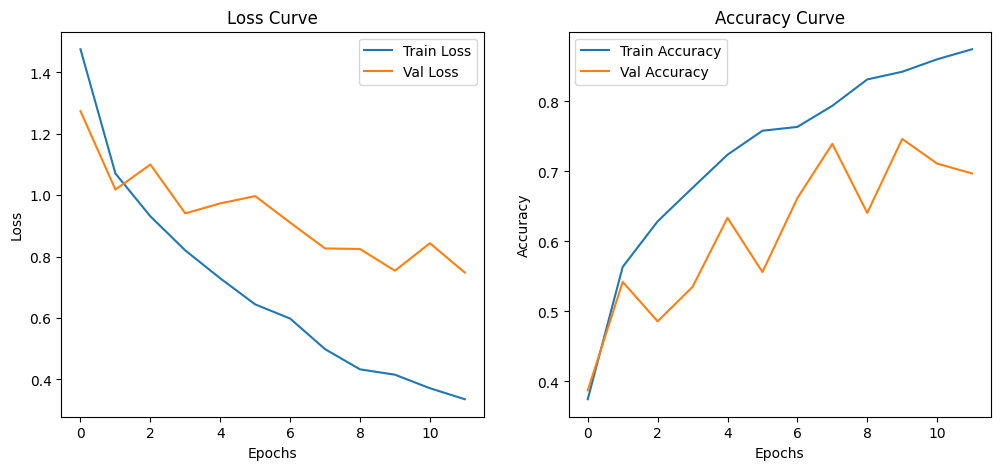

In [ ]:
epochs_range = range(len(train_losses))

plt.figure(figsize=(12, 5))

# Loss Curves
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accs, label="Train Accuracy")
plt.plot(epochs_range, val_accs, label="Val Accuracy")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

### Classification Report

In [ ]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

report = classification_report(
    all_labels,
    all_preds,
    target_names=train_ds.classes
)

print("Classification Report:\n")
print(report)

Classification Report:

                                                  precision    recall  f1-score   support

                                    Bengin cases       0.09      0.22      0.13         9
                                 Malignant cases       0.87      0.95      0.91        21
      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.81      0.74      0.77        23
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.88      0.71      0.79        21
                                          normal       0.81      0.55      0.65        53
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.57      0.87      0.68        15

                                        accuracy                           0.68       142
                                       macro avg       0.67      0.67      0.66       142
                                    weighted avg       0.76      0.68      0.70       142

